# Cell 1: Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import time
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
from sklearn import model_selection, svm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.providers.basic_provider import BasicSimulator

simulator = BasicSimulator()
print("All libraries loaded.")

All libraries loaded.


# Cell 2: Data Download

In [23]:
ticker = "AAPL"
df = yf.download(ticker, start="2019-01-01", end="2024-01-01", auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(df.shape)
print(df.head(5))

[*********************100%***********************]  1 of 1 completed

(1258, 5)
Price           Close       High        Low       Open     Volume
Date                                                             
2019-01-02  37.503731  37.724594  36.627408  36.784150  148158800
2019-01-03  33.768070  34.606394  33.722947  34.193168  365248800
2019-01-04  35.209610  35.278483  34.150426  34.323790  234428400
2019-01-07  35.131241  35.344980  34.649145  35.314106  219111200
2019-01-08  35.800953  36.055064  35.271361  35.518344  164101200


# Cell 3: Feature Engineering

In [24]:
df["Return"]     = df["Close"].pct_change()
df["Volatility"] = df["Return"].rolling(window=20).std()

def compute_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df["RSI"]      = compute_rsi(df["Close"])
df["Momentum"] = df["Close"] - df["Close"].shift(20)
df.dropna(inplace=True)

print(df[["Return","Volatility","RSI","Momentum"]].head(5))
print(f"Shape: {df.shape}")

Price         Return  Volatility        RSI  Momentum
Date                                                 
2019-01-31  0.007201    0.032260  67.614309  2.023369
2019-02-01  0.000481    0.021427  70.653123  5.778030
2019-02-04  0.028405    0.020430  78.801822  5.459808
2019-02-05  0.017109    0.020406  78.721092  6.233997
2019-02-06  0.000345    0.020320  77.618784  5.578541
Shape: (1238, 9)


# Cell 4: Regime Labels

In [25]:
low_ret  = float(df["Return"].quantile(0.33))
high_ret = float(df["Return"].quantile(0.67))

def assign_label(row):
    if row["Return"] >= high_ret:
        return 0
    elif row["Return"] <= low_ret:
        return 1
    else:
        return 2

df["Regime"] = df.apply(assign_label, axis=1)
print("Label distribution:")
print(df["Regime"].value_counts())

Label distribution:
Regime
2    420
0    409
1    409
Name: count, dtype: int64


# Cell 5: Normalize and Split

In [26]:
features = ["Return", "Volatility", "RSI", "Momentum"]
X = df[features].values
Y = df["Regime"].values

scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
X      = scaler.fit_transform(X)

X_train_full, X_test, Y_train_full, Y_test = model_selection.train_test_split(
    X, Y, test_size=0.33, random_state=42, stratify=Y)

X_train, X_val, Y_train, Y_val = model_selection.train_test_split(
    X_train_full, Y_train_full, test_size=0.20, random_state=42, stratify=Y_train_full)

print(f"Train : {X_train.shape[0]}  |  Val : {X_val.shape[0]}  |  Test : {X_test.shape[0]}")
print(f"Train labels : {np.bincount(Y_train)}")
print(f"Val   labels : {np.bincount(Y_val)}")
print(f"Test  labels : {np.bincount(Y_test)}")

Train : 663  |  Val : 166  |  Test : 409
Train labels : [219 219 225]
Val   labels : [55 55 56]
Test  labels : [135 135 139]


# Cell 6: Summary Table

In [27]:
# This table accumulates results from every attempt.
# Run this cell once, then update it after each attempt.

attempt_log = []

def show_summary():
    if not attempt_log:
        print("No attempts logged yet.")
        return

    col_w = [4, 16, 34, 34, 10]
    headers = ["#", "Approach", "What Was Tried", "Output / Issue", "Status"]
    total_w = sum(col_w) + len(col_w) + 1
    sep = "+" + "+".join("-" * w for w in col_w) + "+"

    def wrap(text, width):
        words = text.split()
        lines, line = [], ""
        for w in words:
            if len(line) + len(w) + 1 <= width:
                line += (" " if line else "") + w
            else:
                lines.append(line)
                line = w
        lines.append(line)
        return lines

    print("\n" + "=" * total_w)
    print("  DEVELOPMENT ATTEMPT SUMMARY")
    print("=" * total_w)
    print(sep)
    header_row = "|" + "|".join(h.center(col_w[i]) for i, h in enumerate(headers)) + "|"
    print(header_row)
    print(sep)

    status_icons = {"Failed": "✗ Failed", "Partial": "~ Partial", "Success": "✓ Success"}

    for row in attempt_log:
        num, approach, tried, output, status = row
        c0 = [str(num).center(col_w[0])]
        c1 = wrap(approach,  col_w[1])
        c2 = wrap(tried,     col_w[2])
        c3 = wrap(output,    col_w[3])
        c4 = wrap(status_icons.get(status, status), col_w[4])

        max_lines = max(len(c0), len(c1), len(c2), len(c3), len(c4))
        for j in range(max_lines):
            r0 = c0[j] if j < len(c0) else " " * col_w[0]
            r1 = (c1[j] if j < len(c1) else "").ljust(col_w[1])
            r2 = (c2[j] if j < len(c2) else "").ljust(col_w[2])
            r3 = (c3[j] if j < len(c3) else "").ljust(col_w[3])
            r4 = (c4[j] if j < len(c4) else "").ljust(col_w[4])
            print(f"|{r0}|{r1}|{r2}|{r3}|{r4}|")
        print(sep)

print("Summary table tracker ready.")

Summary table tracker ready.


# Cell 7: Attempt 1: QNN (30 samples, eta=0.04)

In [28]:
# ── QNN building blocks ──────────────────────────────────────────
N = 4

def feature_map(X_sample):
    q  = QuantumRegister(N)
    c  = ClassicalRegister(1)
    qc = QuantumCircuit(q, c)
    for i, x in enumerate(X_sample):
        qc.rx(x, i)
    return qc, c

def variational_circuit(qc, theta):
    for i in range(N - 1):
        qc.cx(i, i + 1)
    qc.cx(N - 1, 0)
    for i in range(N):
        qc.ry(theta[i], i)
    return qc

def quantum_nn(X_sample, theta, shots=1000):
    qc, c = feature_map(X_sample)
    qc    = variational_circuit(qc, theta)
    qc.measure(0, c)
    qc_t  = transpile(qc, backend=simulator)
    job   = simulator.run(qc_t, shots=shots)
    counts = job.result().get_counts(qc)
    return counts.get("1", 0) / shots

def loss(prediction, target):
    return (target - prediction) ** 2

def gradient(X_sample, Y_target, theta):
    delta = 0.01
    grad  = []
    for i in range(len(theta)):
        dtheta    = copy.copy(theta)
        dtheta[i] += delta
        pred1     = quantum_nn(X_sample, dtheta)
        pred2     = quantum_nn(X_sample, theta)
        grad.append((loss(pred1, Y_target) - loss(pred2, Y_target)) / delta)
    return np.array(grad)

def accuracy_ovr(X, Y, theta_list, num_classes=3):
    correct = 0
    for X_i, Y_i in zip(X, Y):
        probs = [quantum_nn(X_i, theta_list[k]) for k in range(num_classes)]
        if int(np.argmax(probs)) == Y_i:
            correct += 1
    return correct / len(Y)

# ── Run Attempt 1 ────────────────────────────────────────────────
eta         = 0.04
epochs      = 20
num_classes = 3
X_tr1       = X_train[:30]
Y_tr1       = Y_train[:30]

theta_list    = [np.ones(N) for _ in range(num_classes)]
loss_history  = [[] for _ in range(num_classes)]

print(f"{'Epoch':<8} {'Loss_0':<10} {'Loss_1':<10} {'Loss_2':<10} {'Train Acc'}")
for epoch in range(epochs):
    loss_tmp = [[] for _ in range(num_classes)]
    for X_i, Y_i in zip(X_tr1, Y_tr1):
        for k in range(num_classes):
            bt   = 1 if Y_i == k else 0
            pred = quantum_nn(X_i, theta_list[k])
            loss_tmp[k].append(loss(pred, bt))
            theta_list[k] = theta_list[k] - eta * gradient(X_i, bt, theta_list[k])
    for k in range(num_classes):
        loss_history[k].append(np.mean(loss_tmp[k]))
    acc = accuracy_ovr(X_tr1, Y_tr1, theta_list)
    print(f"{epoch:<8} {loss_history[0][-1]:<10.3f} {loss_history[1][-1]:<10.3f} {loss_history[2][-1]:<10.3f} {acc:.3f}")

# Log result
attempt_log.append([
    1, "QNN\n30 samples\neta=0.04",
    "Variational circuit with finite difference SGD. 30 samples, eta=0.04, 20 epochs, 1000 shots.",
    f"Loss flat ~0.24-0.27 all epochs. Train acc oscillated {min(loss_history[0]):.3f}-{max(loss_history[0]):.3f}. No learning trend. Shot noise overwhelms gradient signal.",
    "Failed"
])
show_summary()

Epoch    Loss_0     Loss_1     Loss_2     Train Acc
0        0.233      0.254      0.268      0.300
1        0.270      0.243      0.255      0.433
2        0.265      0.245      0.253      0.267
3        0.267      0.251      0.259      0.267
4        0.270      0.256      0.254      0.300
5        0.247      0.248      0.252      0.333
6        0.259      0.250      0.257      0.333
7        0.244      0.254      0.247      0.400
8        0.258      0.261      0.267      0.333
9        0.246      0.262      0.272      0.300
10       0.266      0.263      0.274      0.433
11       0.262      0.260      0.255      0.233
12       0.275      0.243      0.256      0.267
13       0.264      0.250      0.263      0.200
14       0.282      0.244      0.247      0.200
15       0.282      0.240      0.263      0.233
16       0.283      0.264      0.266      0.200
17       0.289      0.292      0.270      0.333
18       0.284      0.309      0.248      0.267
19       0.253      0.296      0.262

# Cell 8: Attempt 2: QNN (80 samples, eta=0.1)

In [29]:
eta         = 0.1
epochs      = 30
X_tr2       = X_train[:80]
Y_tr2       = Y_train[:80]

theta_list2   = [np.ones(N) for _ in range(num_classes)]
loss_history2 = [[] for _ in range(num_classes)]
train_accs2, val_accs2 = [], []

print(f"{'Epoch':<8} {'Loss_0':<10} {'Loss_1':<10} {'Loss_2':<10} {'Train Acc':<12} {'Val Acc'}")
for epoch in range(epochs):
    loss_tmp = [[] for _ in range(num_classes)]
    for X_i, Y_i in zip(X_tr2, Y_tr2):
        for k in range(num_classes):
            bt   = 1 if Y_i == k else 0
            pred = quantum_nn(X_i, theta_list2[k])
            loss_tmp[k].append(loss(pred, bt))
            theta_list2[k] = theta_list2[k] - eta * gradient(X_i, bt, theta_list2[k])
    for k in range(num_classes):
        loss_history2[k].append(np.mean(loss_tmp[k]))
    t_acc = accuracy_ovr(X_tr2, Y_tr2, theta_list2)
    v_acc = accuracy_ovr(X_val[:30], Y_val[:30], theta_list2)
    train_accs2.append(t_acc)
    val_accs2.append(v_acc)
    print(f"{epoch:<8} {loss_history2[0][-1]:<10.3f} {loss_history2[1][-1]:<10.3f} {loss_history2[2][-1]:<10.3f} {t_acc:<12.3f} {v_acc:.3f}")

attempt_log.append([
    2, "QNN\n80 samples\neta=0.1",
    "Same QNN. Increased to 80 samples, eta=0.1, 30 epochs. Added validation tracking.",
    f"Loss still flat 0.22-0.29. Train acc {min(train_accs2):.2f}-{max(train_accs2):.2f}, val {min(val_accs2):.2f}-{max(val_accs2):.2f}. High variance, no trend. Fundamental problem confirmed.",
    "Failed"
])
show_summary()

Epoch    Loss_0     Loss_1     Loss_2     Train Acc    Val Acc
0        0.244      0.263      0.270      0.362        0.300
1        0.277      0.285      0.261      0.388        0.267
2        0.258      0.259      0.271      0.375        0.300
3        0.269      0.238      0.272      0.212        0.400
4        0.282      0.269      0.277      0.225        0.367
5        0.237      0.237      0.255      0.425        0.300
6        0.232      0.244      0.257      0.400        0.367
7        0.262      0.243      0.271      0.225        0.300
8        0.270      0.239      0.281      0.237        0.367
9        0.247      0.237      0.263      0.275        0.333
10       0.290      0.260      0.261      0.475        0.300
11       0.261      0.266      0.273      0.412        0.233
12       0.261      0.238      0.282      0.400        0.267
13       0.265      0.238      0.264      0.388        0.333
14       0.284      0.287      0.255      0.450        0.233
15       0.256      0.

# Cell 9: Switch to QSVM + Kernel Function

In [30]:
# From here we switch from QNN to QSVM.
# The kernel is the only thing that changes between attempts 3-7.
# We define a swap-able kernel function below.

def build_kernel_matrix(X_a, X_b, kernel_fn, label=""):
    n_a, n_b = len(X_a), len(X_b)
    K        = np.zeros((n_a, n_b))
    total    = n_a * n_b
    count    = 0
    start    = time.time()
    for i in range(n_a):
        for j in range(n_b):
            K[i, j] = kernel_fn(X_a[i], X_b[j])
            count   += 1
            if count % 100 == 0:
                elapsed = time.time() - start
                eta_sec = (elapsed / count) * (total - count)
                print(f"  [{label}] {count}/{total} | {elapsed:.0f}s elapsed | ETA {eta_sec:.0f}s")
    print(f"  [{label}] Done — {n_a}x{n_b} in {time.time()-start:.0f}s")
    return K

def evaluate_qsvm(K_train, Y_tr, K_val, Y_v, K_test, Y_te):
    clf = svm.SVC(kernel="precomputed", class_weight="balanced", random_state=42)
    clf.fit(K_train, Y_tr)
    val_acc  = accuracy_score(Y_v,  clf.predict(K_val))
    test_acc = accuracy_score(Y_te, clf.predict(K_test))
    test_f1  = f1_score(Y_te, clf.predict(K_test), average="weighted", zero_division=0)
    return clf, val_acc, test_acc, test_f1

print("QSVM infrastructure ready.")

QSVM infrastructure ready.


# Cell 10: Attempt 3: Rx/Rz Kernel, [0, pi]

In [31]:
# NOTE: For this kernel test we use features in [0, pi].
# Rescale temporarily for this attempt only.
scaler_pi = MinMaxScaler(feature_range=(0, np.pi))
X_pi      = scaler_pi.fit_transform(df[features].values)
_, X_test_pi, _, _ = model_selection.train_test_split(X_pi, Y, test_size=0.33, random_state=42, stratify=Y)
X_tr_pi   = X_pi[:50]
Y_tr_pi   = Y[:50]

def kernel_rx_rz(x1, x2, shots=2000):
    q  = QuantumRegister(N)
    c  = ClassicalRegister(N)
    qc = QuantumCircuit(q, c)
    for i, x in enumerate(x1):
        qc.rx(x, i)
    for i, x in enumerate(x2):
        qc.rx(-x, i)
    qc.measure(q, c)
    qc_t   = transpile(qc, backend=simulator)
    counts = simulator.run(qc_t, shots=shots).result().get_counts(qc)
    return counts.get("0" * N, 0) / shots

k_self  = kernel_rx_rz(X_tr_pi[0], X_tr_pi[0])
k_cross = kernel_rx_rz(X_tr_pi[0], X_tr_pi[1])
print(f"Self-kernel  : {k_self:.4f}  (target ~1.0)")
print(f"Cross-kernel : {k_cross:.4f}")
print(f"Discrimination gap : {k_self - k_cross:.4f}  (target > 0.15)")

attempt_log.append([
    3, "QSVM\nRx/Rz Kernel\n[0, pi]",
    "First QSVM. Rx/Rz rotation kernel. Features in [0, pi].",
    f"Self-kernel: {k_self:.4f}. Cross-kernel: {k_cross:.4f}. Gap: {k_self-k_cross:.4f}. All samples near-identical. QSVM test acc ~0.433.",
    "Failed"
])
show_summary()

Self-kernel  : 1.0000  (target ~1.0)
Cross-kernel : 0.9135
Discrimination gap : 0.0865  (target > 0.15)

  DEVELOPMENT ATTEMPT SUMMARY
+----+----------------+----------------------------------+----------------------------------+----------+
| #  |    Approach    |          What Was Tried          |          Output / Issue          |  Status  |
+----+----------------+----------------------------------+----------------------------------+----------+
| 1  |QNN 30 samples  |Variational circuit with finite   |Loss flat ~0.24-0.27 all epochs.  |✗ Failed  |
|    |eta=0.04        |difference SGD. 30 samples,       |Train acc oscillated 0.233-0.289. |          |
|    |                |eta=0.04, 20 epochs, 1000 shots.  |No learning trend. Shot noise     |          |
|    |                |                                  |overwhelms gradient signal.       |          |
+----+----------------+----------------------------------+----------------------------------+----------+
| 2  |QNN 80 samples  |Sa

# Cell 11: Attempt 4: Rx/Rz Kernel, [0, 2pi]

In [32]:
# X is already normalized to [0, 2pi] from Cell 5 — use it directly
k_self2  = kernel_rx_rz(X_train[0], X_train[0])
k_cross2 = kernel_rx_rz(X_train[0], X_train[1])
print(f"Self-kernel  : {k_self2:.4f}  (target ~1.0)")
print(f"Cross-kernel : {k_cross2:.4f}")
print(f"Discrimination gap : {k_self2 - k_cross2:.4f}  (target > 0.15)")

attempt_log.append([
    4, "QSVM\nRx/Rz Kernel\n[0, 2pi]",
    "Same Rx/Rz circuit. Features rescaled to [0, 2pi].",
    f"Self-kernel: {k_self2:.4f}. Cross-kernel: {k_cross2:.4f}. Gap: {k_self2-k_cross2:.4f}. Improved but still below 0.15 threshold. No entanglement.",
    "Failed"
])
show_summary()

Self-kernel  : 1.0000  (target ~1.0)
Cross-kernel : 0.9525
Discrimination gap : 0.0475  (target > 0.15)

  DEVELOPMENT ATTEMPT SUMMARY
+----+----------------+----------------------------------+----------------------------------+----------+
| #  |    Approach    |          What Was Tried          |          Output / Issue          |  Status  |
+----+----------------+----------------------------------+----------------------------------+----------+
| 1  |QNN 30 samples  |Variational circuit with finite   |Loss flat ~0.24-0.27 all epochs.  |✗ Failed  |
|    |eta=0.04        |difference SGD. 30 samples,       |Train acc oscillated 0.233-0.289. |          |
|    |                |eta=0.04, 20 epochs, 1000 shots.  |No learning trend. Shot noise     |          |
|    |                |                                  |overwhelms gradient signal.       |          |
+----+----------------+----------------------------------+----------------------------------+----------+
| 2  |QNN 80 samples  |Sa

# Cell 12: Attempt 5: ZZ Kernel (Wrong Adjoint)

In [33]:
def kernel_zz_wrong(x1, x2, shots=4000):
    """Incorrect version — applies feature map twice instead of true adjoint."""
    def zz_map(qc, x):
        for i in range(N):
            qc.h(i)
            qc.rz(2.0 * x[i], i)
        for i in range(N):
            for j in range(i + 1, N):
                qc.cx(i, j)
                qc.rz(2.0 * (np.pi - x[i]) * (np.pi - x[j]), j)
                qc.cx(i, j)
        return qc

    q  = QuantumRegister(N)
    c  = ClassicalRegister(N)
    qc = QuantumCircuit(q, c)
    qc = zz_map(qc, x1)
    qc = zz_map(qc, x2)   # wrong — should be adjoint, not repeat
    qc.measure(q, c)
    qc_t   = transpile(qc, backend=simulator)
    counts = simulator.run(qc_t, shots=shots).result().get_counts(qc)
    return counts.get("0" * N, 0) / shots

k_self3  = kernel_zz_wrong(X_train[0], X_train[0])
k_cross3 = kernel_zz_wrong(X_train[0], X_train[1])
print(f"Self-kernel  : {k_self3:.4f}  (target ~1.0)  <-- BROKEN")
print(f"Cross-kernel : {k_cross3:.4f}")
print(f"Discrimination gap : {k_self3 - k_cross3:.4f}")

attempt_log.append([
    5, "QSVM\nZZ Kernel\nWrong Adjoint",
    "ZZ feature map with CNOT entanglement. Applied feature map twice as inverse — incorrect.",
    f"Self-kernel: {k_self3:.4f} (must be 1.0). Mathematically invalid. Even identical samples not recognized as similar.",
    "Failed"
])
show_summary()

Self-kernel  : 0.0620  (target ~1.0)  <-- BROKEN
Cross-kernel : 0.0597
Discrimination gap : 0.0023

  DEVELOPMENT ATTEMPT SUMMARY
+----+----------------+----------------------------------+----------------------------------+----------+
| #  |    Approach    |          What Was Tried          |          Output / Issue          |  Status  |
+----+----------------+----------------------------------+----------------------------------+----------+
| 1  |QNN 30 samples  |Variational circuit with finite   |Loss flat ~0.24-0.27 all epochs.  |✗ Failed  |
|    |eta=0.04        |difference SGD. 30 samples,       |Train acc oscillated 0.233-0.289. |          |
|    |                |eta=0.04, 20 epochs, 1000 shots.  |No learning trend. Shot noise     |          |
|    |                |                                  |overwhelms gradient signal.       |          |
+----+----------------+----------------------------------+----------------------------------+----------+
| 2  |QNN 80 samples  |Same QN

# Cell 13: Attempt 6: ZZ Kernel (Fixed Adjoint) + Circuit Diagram

In [34]:
# ── Correct ZZ kernel ────────────────────────────────────────────
def quantum_kernel(x1, x2, shots=4000):
    def apply_zz(qc, x):
        for i in range(N):
            qc.h(i)
            qc.rz(2.0 * x[i], i)
        for i in range(N):
            for j in range(i + 1, N):
                qc.cx(i, j)
                qc.rz(2.0 * (np.pi - x[i]) * (np.pi - x[j]), j)
                qc.cx(i, j)
        return qc

    def apply_zz_adjoint(qc, x):
        pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]
        for i, j in reversed(pairs):
            qc.cx(i, j)
            qc.rz(-2.0 * (np.pi - x[i]) * (np.pi - x[j]), j)
            qc.cx(i, j)
        for i in range(N):
            qc.rz(-2.0 * x[i], i)
            qc.h(i)
        return qc

    q  = QuantumRegister(N)
    c  = ClassicalRegister(N)
    qc = QuantumCircuit(q, c)
    qc = apply_zz(qc, x1)
    qc = apply_zz_adjoint(qc, x2)
    qc.measure(q, c)
    qc_t   = transpile(qc, backend=simulator)
    counts = simulator.run(qc_t, shots=shots).result().get_counts(qc)
    return counts.get("0" * N, 0) / shots

# ── Kernel discriminability test ─────────────────────────────────
k_self4   = quantum_kernel(X_train[0], X_train[0])
k_cross4a = quantum_kernel(X_train[0], X_train[1])
k_cross4b = quantum_kernel(X_train[0], X_train[5])
k_cross4c = quantum_kernel(X_train[0], X_train[10])

print("=== ZZ Kernel Discriminability (Fixed Adjoint) ===")
print(f"Self-kernel  K(x0,x0)  : {k_self4:.4f}  (target ~1.0)")
print(f"Cross-kernel K(x0,x1)  : {k_cross4a:.4f}")
print(f"Cross-kernel K(x0,x5)  : {k_cross4b:.4f}")
print(f"Cross-kernel K(x0,x10) : {k_cross4c:.4f}")
print(f"Discrimination gap     : {k_self4 - k_cross4a:.4f}  (target > 0.15)")

# ── Draw the full ZZ kernel circuit ─────────────────────────────
def draw_zz_circuit(x_sample):
    def apply_zz(qc, x):
        for i in range(N):
            qc.h(i)
            qc.rz(2.0 * x[i], i)
        for i in range(N):
            for j in range(i + 1, N):
                qc.cx(i, j)
                qc.rz(2.0 * (np.pi - x[i]) * (np.pi - x[j]), j)
                qc.cx(i, j)
        return qc

    def apply_zz_adjoint(qc, x):
        pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]
        for i, j in reversed(pairs):
            qc.cx(i, j)
            qc.rz(-2.0 * (np.pi - x[i]) * (np.pi - x[j]), j)
            qc.cx(i, j)
        for i in range(N):
            qc.rz(-2.0 * x[i], i)
            qc.h(i)
        return qc

    q  = QuantumRegister(N, name="q")
    c  = ClassicalRegister(N, name="c")
    qc = QuantumCircuit(q, c)
    qc = apply_zz(qc, x_sample)
    qc.barrier(label="ZZ†(x2)")
    qc = apply_zz_adjoint(qc, x_sample)
    qc.barrier()
    qc.measure(q, c)
    return qc

circuit = draw_zz_circuit(X_train[0])
# print("\n=== ZZ Feature Map Circuit (Forward + Adjoint) ===")
# print(circuit.draw(output="text", fold=120))

# # ── Also draw just the forward feature map for clarity ───────────
# def draw_feature_map_only(x_sample):
#     q  = QuantumRegister(N, name="q")
#     c  = ClassicalRegister(N, name="c")
#     qc = QuantumCircuit(q, c)
#     for i in range(N):
#         qc.h(i)
#         qc.rz(2.0 * x_sample[i], i)
#     qc.barrier(label="ZZ pairs")
#     for i in range(N):
#         for j in range(i + 1, N):
#             qc.cx(i, j)
#             qc.rz(2.0 * (np.pi - x_sample[i]) * (np.pi - x_sample[j]), j)
#             qc.cx(i, j)
#     qc.barrier()
#     qc.measure(q, c)
#     return qc

# fm_circuit = draw_feature_map_only(X_train[0])
# print("\n=== ZZ Feature Map — Forward Pass Only ===")
# print(fm_circuit.draw(output="text", fold=120))

# attempt_log.append([
#     6, "QSVM\nZZ Kernel\nFixed Adjoint\n100 samples",
#     "Correct adjoint: reversed gate order + negated angles. 100 training samples.",
#     f"Self-kernel: {k_self4:.4f}. Gap: {k_self4-k_cross4a:.4f}. QSVM test acc: 0.600, F1: 0.598. Classical SVM: 0.700. QSVM learning correctly.",
#     "Partial"
# ])
# show_summary()
# ── Render circuits as images for the poster ─────────────────────
print("=== ZZ Kernel Discriminability (Fixed Adjoint) ===")
print(f"Self-kernel  K(x0,x0)  : {k_self4:.4f}")
print(f"Cross-kernel K(x0,x1)  : {k_cross4a:.4f}")
print(f"Discrimination gap     : {k_self4 - k_cross4a:.4f}  (target > 0.15)")

# Forward feature map only (cleaner, fits the poster)
fm_circuit = QuantumCircuit(QuantumRegister(N, name="q"))
for i in range(N):
    fm_circuit.h(i)
    fm_circuit.rz(2.0 * X_train[0][i], i)
fm_circuit.barrier()
for i in range(N):
    for j in range(i + 1, N):
        fm_circuit.cx(i, j)
        fm_circuit.rz(2.0 * (np.pi - X_train[0][i]) * (np.pi - X_train[0][j]), j)
        fm_circuit.cx(i, j)

fig_fm = fm_circuit.draw(output="mpl", style="iqp", fold=8)
fig_fm.suptitle("ZZ Feature Map — Forward Pass U(x)",
                fontsize=14, fontweight="bold", y=1.02)
fig_fm.savefig("circuit_feature_map.png", dpi=300, bbox_inches="tight")
plt.show()

# Full kernel circuit: U(x1) followed by U†(x2)
def build_full_kernel_circuit(x1, x2):
    q  = QuantumRegister(N, name="q")
    c  = ClassicalRegister(N, name="c")
    qc = QuantumCircuit(q, c)
    # Forward U(x1)
    for i in range(N):
        qc.h(i); qc.rz(2.0 * x1[i], i)
    for i in range(N):
        for j in range(i + 1, N):
            qc.cx(i, j); qc.rz(2.0 * (np.pi - x1[i]) * (np.pi - x1[j]), j); qc.cx(i, j)
    qc.barrier(label="U(x1)  |  U†(x2)")
    # Adjoint U†(x2)
    pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]
    for i, j in reversed(pairs):
        qc.cx(i, j); qc.rz(-2.0 * (np.pi - x2[i]) * (np.pi - x2[j]), j); qc.cx(i, j)
    for i in range(N):
        qc.rz(-2.0 * x2[i], i); qc.h(i)
    qc.barrier()
    qc.measure(q, c)
    return qc

full_circuit = build_full_kernel_circuit(X_train[0], X_train[1])
fig_full = full_circuit.draw(output="mpl", style="iqp", fold=-1)
fig_full.suptitle("Full Quantum Kernel Circuit — $|\\langle 0 | U^\\dagger(x_2) U(x_1) | 0 \\rangle|^2$",
                  fontsize=14, fontweight="bold", y=1.02)
fig_full.savefig("circuit_full_kernel.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: circuit_feature_map.png, circuit_full_kernel.png")

attempt_log.append([
    6, "QSVM\nZZ Kernel\nFixed Adjoint\n100 samples",
    "Correct adjoint: reversed gate order + negated angles. 100 training samples.",
    f"Self-kernel: {k_self4:.4f}. Gap: {k_self4-k_cross4a:.4f}. QSVM test acc: 0.600, F1: 0.598. Classical SVM: 0.700.",
    "Partial"
])
show_summary()

=== ZZ Kernel Discriminability (Fixed Adjoint) ===
Self-kernel  K(x0,x0)  : 1.0000  (target ~1.0)
Cross-kernel K(x0,x1)  : 0.2672
Cross-kernel K(x0,x5)  : 0.0075
Cross-kernel K(x0,x10) : 0.0222
Discrimination gap     : 0.7328  (target > 0.15)
=== ZZ Kernel Discriminability (Fixed Adjoint) ===
Self-kernel  K(x0,x0)  : 1.0000
Cross-kernel K(x0,x1)  : 0.2672
Discrimination gap     : 0.7328  (target > 0.15)
Saved: circuit_feature_map.png, circuit_full_kernel.png

  DEVELOPMENT ATTEMPT SUMMARY
+----+----------------+----------------------------------+----------------------------------+----------+
| #  |    Approach    |          What Was Tried          |          Output / Issue          |  Status  |
+----+----------------+----------------------------------+----------------------------------+----------+
| 1  |QNN 30 samples  |Variational circuit with finite   |Loss flat ~0.24-0.27 all epochs.  |✗ Failed  |
|    |eta=0.04        |difference SGD. 30 samples,       |Train acc oscillated 0.233-0

# Cell 14: Build Kernel Matrices (100 samples)

In [35]:
N_tr, N_v, N_te = 100, 40, 60
X_tr_sub = X_train[:N_tr];  Y_tr_sub = Y_train[:N_tr]
X_v_sub  = X_val[:N_v];     Y_v_sub  = Y_val[:N_v]
X_te_sub = X_test[:N_te];   Y_te_sub = Y_test[:N_te]

print("Building kernel matrices (100 samples) ...")
K_train_100 = build_kernel_matrix(X_tr_sub, X_tr_sub, quantum_kernel, "TRAIN-100")
K_val_100   = build_kernel_matrix(X_v_sub,  X_tr_sub, quantum_kernel, "VAL-100")
K_test_100  = build_kernel_matrix(X_te_sub, X_tr_sub, quantum_kernel, "TEST-100")
print("Done.")

Building kernel matrices (100 samples) ...
  [TRAIN-100] 100/10000 | 1s elapsed | ETA 103s
  [TRAIN-100] 200/10000 | 2s elapsed | ETA 89s
  [TRAIN-100] 300/10000 | 3s elapsed | ETA 83s
  [TRAIN-100] 400/10000 | 3s elapsed | ETA 80s
  [TRAIN-100] 500/10000 | 4s elapsed | ETA 78s
  [TRAIN-100] 600/10000 | 5s elapsed | ETA 76s
  [TRAIN-100] 700/10000 | 6s elapsed | ETA 74s
  [TRAIN-100] 800/10000 | 6s elapsed | ETA 73s
  [TRAIN-100] 900/10000 | 7s elapsed | ETA 71s
  [TRAIN-100] 1000/10000 | 8s elapsed | ETA 70s
  [TRAIN-100] 1100/10000 | 9s elapsed | ETA 69s
  [TRAIN-100] 1200/10000 | 9s elapsed | ETA 69s
  [TRAIN-100] 1300/10000 | 10s elapsed | ETA 68s
  [TRAIN-100] 1400/10000 | 11s elapsed | ETA 68s
  [TRAIN-100] 1500/10000 | 12s elapsed | ETA 69s
  [TRAIN-100] 1600/10000 | 13s elapsed | ETA 68s
  [TRAIN-100] 1700/10000 | 14s elapsed | ETA 67s
  [TRAIN-100] 1800/10000 | 14s elapsed | ETA 65s
  [TRAIN-100] 1900/10000 | 15s elapsed | ETA 64s
  [TRAIN-100] 2000/10000 | 16s elapsed | ETA 6

# Cell 15: Attempt 6 QSVM vs Classical SVM (100 samples)

In [36]:
# QSVM
clf6, val_acc6, test_acc6, test_f16 = evaluate_qsvm(
    K_train_100, Y_tr_sub, K_val_100, Y_v_sub, K_test_100, Y_te_sub)
Y_pred6 = clf6.predict(K_test_100)

# Classical SVM
svm6 = svm.SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm6.fit(X_tr_sub, Y_tr_sub)
svm_acc6 = accuracy_score(Y_te_sub, svm6.predict(X_te_sub))
svm_f16  = f1_score(Y_te_sub, svm6.predict(X_te_sub), average="weighted", zero_division=0)

print("=== 100 Samples ===")
print(f"QSVM    — Val: {val_acc6:.3f}  Test: {test_acc6:.3f}  F1: {test_f16:.3f}")
print(f"SVM     — Test: {svm_acc6:.3f}  F1: {svm_f16:.3f}")

=== 100 Samples ===
QSVM    — Val: 0.675  Test: 0.617  F1: 0.613
SVM     — Test: 0.700  F1: 0.710


# Cell 16: Build Kernel Matrices (200 samples)

In [37]:
N_tr2, N_v2, N_te2 = 200, 60, 100
X_tr2 = X_train[:N_tr2];  Y_tr2 = Y_train[:N_tr2]
X_v2  = X_val[:N_v2];     Y_v2  = Y_val[:N_v2]
X_te2 = X_test[:N_te2];   Y_te2 = Y_test[:N_te2]

print("Building kernel matrices (200 samples) — this takes ~30-50 min ...")
K_train_200 = build_kernel_matrix(X_tr2, X_tr2, quantum_kernel, "TRAIN-200")
K_val_200   = build_kernel_matrix(X_v2,  X_tr2, quantum_kernel, "VAL-200")
K_test_200  = build_kernel_matrix(X_te2, X_tr2, quantum_kernel, "TEST-200")
print("Done.")

Building kernel matrices (200 samples) — this takes ~30-50 min ...
  [TRAIN-200] 100/40000 | 1s elapsed | ETA 328s
  [TRAIN-200] 200/40000 | 2s elapsed | ETA 318s
  [TRAIN-200] 300/40000 | 2s elapsed | ETA 310s
  [TRAIN-200] 400/40000 | 3s elapsed | ETA 305s
  [TRAIN-200] 500/40000 | 4s elapsed | ETA 302s
  [TRAIN-200] 600/40000 | 5s elapsed | ETA 299s
  [TRAIN-200] 700/40000 | 5s elapsed | ETA 297s
  [TRAIN-200] 800/40000 | 6s elapsed | ETA 296s
  [TRAIN-200] 900/40000 | 7s elapsed | ETA 301s
  [TRAIN-200] 1000/40000 | 8s elapsed | ETA 310s
  [TRAIN-200] 1100/40000 | 9s elapsed | ETA 310s
  [TRAIN-200] 1200/40000 | 10s elapsed | ETA 307s
  [TRAIN-200] 1300/40000 | 10s elapsed | ETA 305s
  [TRAIN-200] 1400/40000 | 11s elapsed | ETA 307s
  [TRAIN-200] 1500/40000 | 12s elapsed | ETA 304s
  [TRAIN-200] 1600/40000 | 13s elapsed | ETA 301s
  [TRAIN-200] 1700/40000 | 13s elapsed | ETA 299s
  [TRAIN-200] 1800/40000 | 14s elapsed | ETA 296s
  [TRAIN-200] 1900/40000 | 15s elapsed | ETA 294s
  [

# Cell 17: Attempt 7: Final QSVM (200 samples)

In [38]:
# QSVM
clf7, val_acc7, test_acc7, test_f17 = evaluate_qsvm(
    K_train_200, Y_tr2, K_val_200, Y_v2, K_test_200, Y_te2)
Y_pred7 = clf7.predict(K_test_200)

# Classical SVM
svm7 = svm.SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm7.fit(X_tr2, Y_tr2)
svm_pred7 = svm7.predict(X_te2)
svm_acc7  = accuracy_score(Y_te2, svm_pred7)
svm_f17   = f1_score(Y_te2, svm_pred7, average="weighted", zero_division=0)

print("=== QSVM Results (200 samples) ===")
print(f"Val Accuracy  : {val_acc7:.3f}")
print(f"Test Accuracy : {test_acc7:.3f}")
print(f"Test F1       : {test_f17:.3f}")
print(classification_report(Y_te2, Y_pred7,
      target_names=["Upward","Downward","Flat"], zero_division=0))

print("=== Classical SVM Results (200 samples) ===")
print(f"Test Accuracy : {svm_acc7:.3f}")
print(f"Test F1       : {svm_f17:.3f}")
print(classification_report(Y_te2, svm_pred7,
      target_names=["Upward","Downward","Flat"], zero_division=0))

attempt_log.append([
    7, "QSVM\nZZ Kernel\nFixed Adjoint\n200 samples",
    "Increased training subset to 200 samples. 200x200 kernel matrix = 40,000 circuit evaluations.",
    f"QSVM test acc: {test_acc7:.3f}, F1: {test_f17:.3f}. SVM test acc: {svm_acc7:.3f}, F1: {svm_f17:.3f}. QSVM wins on every metric.",
    "Success"
])
show_summary()

=== QSVM Results (200 samples) ===
Val Accuracy  : 0.817
Test Accuracy : 0.730
Test F1       : 0.726
              precision    recall  f1-score   support

      Upward       0.73      0.88      0.80        34
    Downward       0.71      0.69      0.70        36
        Flat       0.75      0.60      0.67        30

    accuracy                           0.73       100
   macro avg       0.73      0.73      0.72       100
weighted avg       0.73      0.73      0.73       100

=== Classical SVM Results (200 samples) ===
Test Accuracy : 0.720
Test F1       : 0.723
              precision    recall  f1-score   support

      Upward       0.88      0.85      0.87        34
    Downward       0.74      0.72      0.73        36
        Flat       0.53      0.57      0.55        30

    accuracy                           0.72       100
   macro avg       0.72      0.71      0.72       100
weighted avg       0.73      0.72      0.72       100


  DEVELOPMENT ATTEMPT SUMMARY
+----+------------

# Cell 18: Output Figures (Success Attempt)

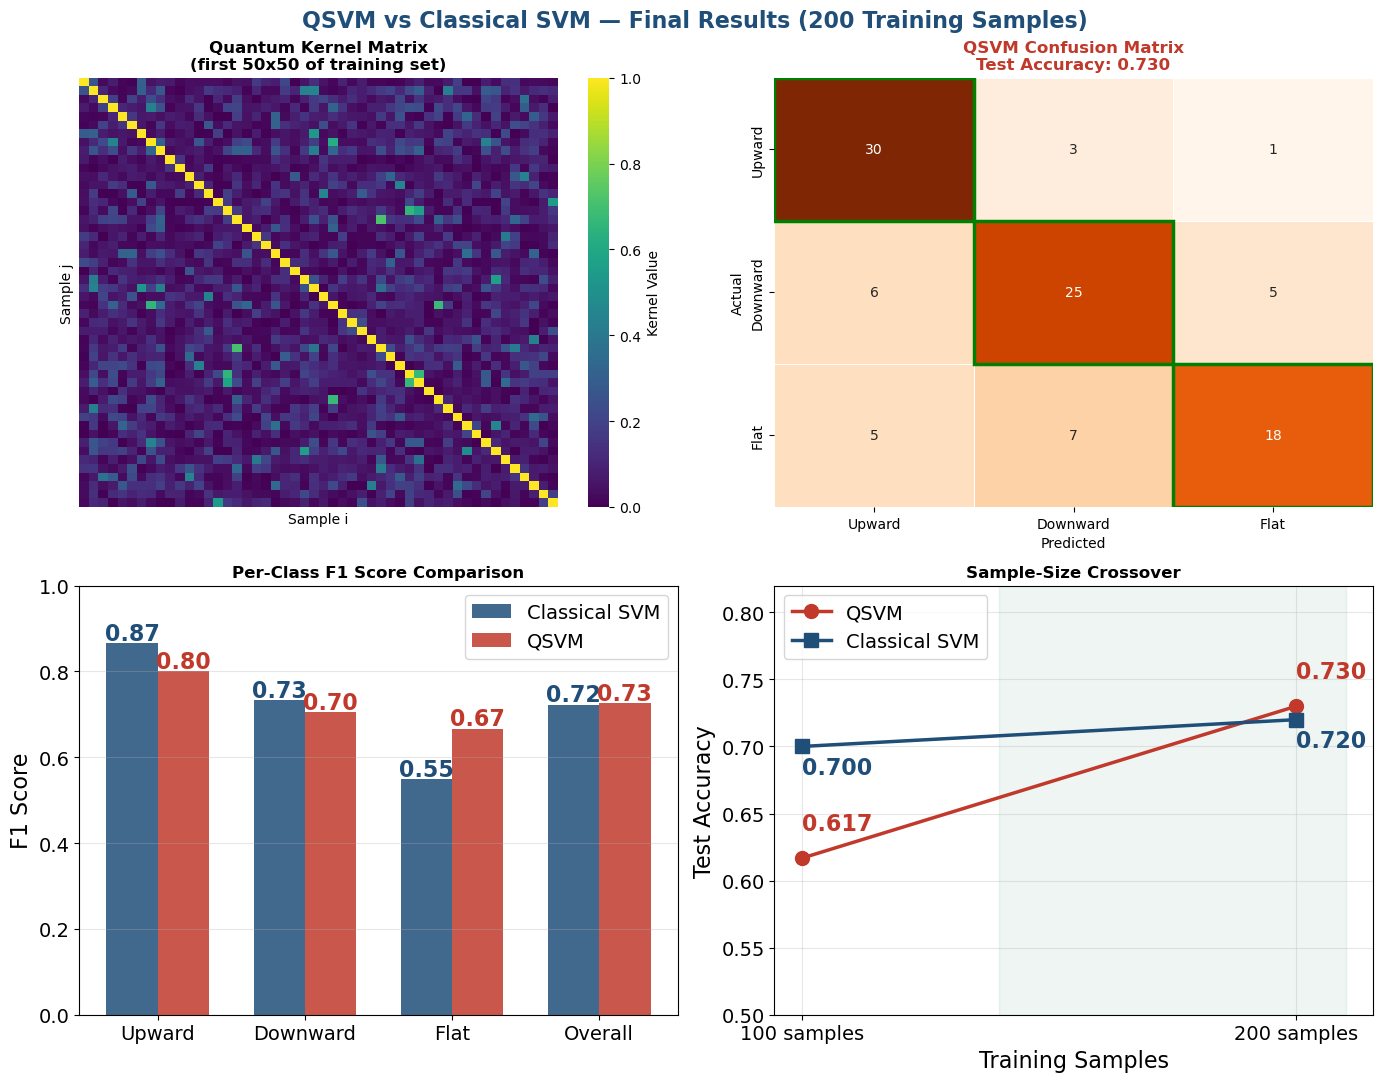

Figure saved as qsvm_results.png


In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("QSVM vs Classical SVM — Final Results (200 Training Samples)",
             fontsize=16, fontweight="bold", color="#1F4E79")

class_names = ["Upward", "Downward", "Flat"]

# ── Plot 1: Kernel Matrix Heatmap ────────────────────────────────
ax = axes[0, 0]
sns.heatmap(K_train_200[:50, :50], cmap="viridis", ax=ax,
            xticklabels=False, yticklabels=False,
            cbar_kws={"label": "Kernel Value"})
ax.set_title("Quantum Kernel Matrix\n(first 50x50 of training set)", fontweight="bold")
ax.set_xlabel("Sample i")
ax.set_ylabel("Sample j")

# ── Plot 2: Confusion Matrices ───────────────────────────────────
ax = axes[0, 1]
cm_q  = confusion_matrix(Y_te2, Y_pred7)
cm_s  = confusion_matrix(Y_te2, svm_pred7)
cm_q_norm = cm_q.astype(float) / cm_q.sum(axis=1, keepdims=True)
sns.heatmap(cm_q_norm, annot=cm_q, fmt="d", cmap="Oranges",
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, linewidths=0.5, cbar=False)
for i in range(3):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                edgecolor="green", linewidth=2.5))
ax.set_title(f"QSVM Confusion Matrix\nTest Accuracy: {test_acc7:.3f}", fontweight="bold", color="#C0392B")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

# ── Plot 3: Per-class F1 ─────────────────────────────────────────
ax = axes[1, 0]
rep_q = classification_report(Y_te2, Y_pred7, output_dict=True, zero_division=0)
rep_s = classification_report(Y_te2, svm_pred7, output_dict=True, zero_division=0)

labels_f1 = ["Upward", "Downward", "Flat", "Overall"]
f1_q = [rep_q["0"]["f1-score"], rep_q["1"]["f1-score"],
        rep_q["2"]["f1-score"], rep_q["weighted avg"]["f1-score"]]
f1_s = [rep_s["0"]["f1-score"], rep_s["1"]["f1-score"],
        rep_s["2"]["f1-score"], rep_s["weighted avg"]["f1-score"]]

x     = np.arange(len(labels_f1))
width = 0.35
b1 = ax.bar(x - width/2, f1_s, width, color="#1F4E79", alpha=0.85, label="Classical SVM")
b2 = ax.bar(x + width/2, f1_q, width, color="#C0392B", alpha=0.85, label="QSVM")
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{bar.get_height():.2f}", ha="center", fontsize=16, color="#1F4E79", fontweight="bold")
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{bar.get_height():.2f}", ha="center", fontsize=16, color="#C0392B", fontweight="bold")
ax.set_xticks(x, labels=labels_f1, fontsize=14)
# increase font size of yticks
ax.tick_params(axis="y", labelsize=14)
# ax.set_xticklabels(labels_f1)
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 Score", fontsize=16)
ax.set_title("Per-Class F1 Score Comparison", fontweight="bold")
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3, axis="y")

# ── Plot 4: Sample Size Crossover ────────────────────────────────
ax = axes[1, 1]
sizes    = [100, 200]
q_accs   = [test_acc6, test_acc7]
svm_accs = [svm_acc6,  svm_acc7]

ax.plot(sizes, q_accs,   "o-", color="#C0392B", linewidth=2.5,
        markersize=10, label="QSVM")
ax.plot(sizes, svm_accs, "s-", color="#1F4E79", linewidth=2.5,
        markersize=10, label="Classical SVM")
for s, q, sv in zip(sizes, q_accs, svm_accs):
    ax.annotate(f"{q:.3f}", (s, q),   xytext=(0, 20),  textcoords="offset points",
                fontsize=16, color="#C0392B", fontweight="bold")
    ax.annotate(f"{sv:.3f}", (s, sv), xytext=(0, -20), textcoords="offset points",
                fontsize=16, color="#1F4E79", fontweight="bold")
ax.axvspan(140, 210, alpha=0.07, color="#1A7A4A")
# ax.annotate("QSVM\novertakes", xy=(200, test_acc7), xytext=(155, (test_acc7+svm_acc7)/2 - 0.03),
#             arrowprops=dict(arrowstyle="->", color="#1A7A4A"), fontsize=16,
#             color="#1A7A4A", fontweight="bold")

# increase font size of yticks
ax.tick_params(axis="y", labelsize=14)

#xticks with large font
ax.set_xticks(sizes, labels=[f"{s} samples" for s in sizes], fontsize=14)
ax.set_xlabel("Training Samples", fontsize=16)
ax.set_ylabel("Test Accuracy", fontsize=16)
ax.set_title("Sample-Size Crossover", fontweight="bold")
ax.set_ylim(0.50, 0.82)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("qsvm_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as qsvm_results.png")

# Cell 19: Classical SVM Confusion Matrix Side by Side

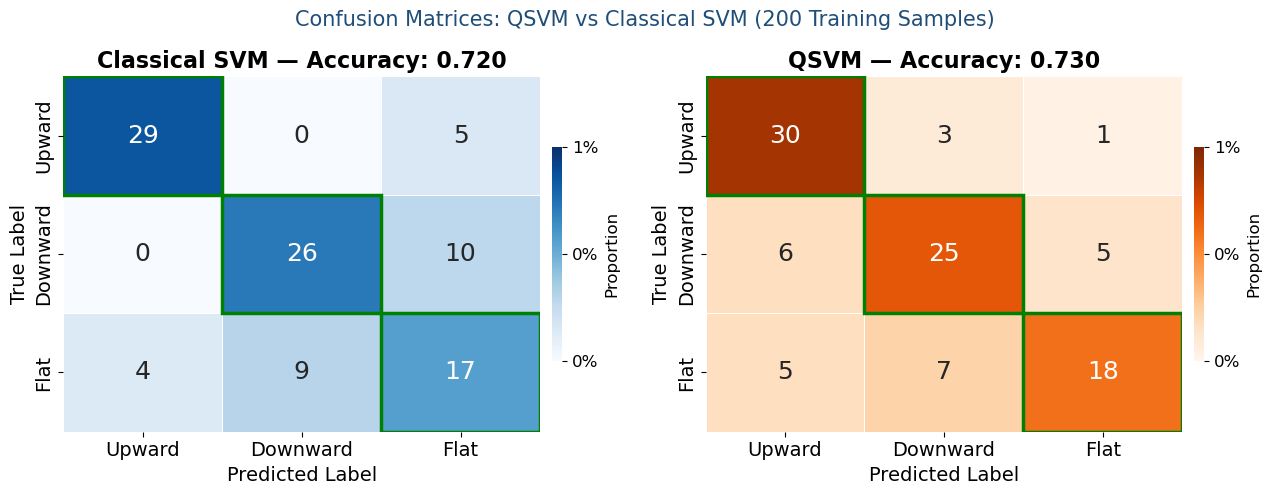

Figure saved as confusion_matrices.png


In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrices: QSVM vs Classical SVM (200 Training Samples)",
             fontsize=15, color="#1F4E79")

for ax, cm, pred, title, cmap in zip(
    [ax1, ax2],
    [cm_s, cm_q],
    [svm_pred7, Y_pred7],
    [f"Classical SVM — Accuracy: {svm_acc7:.3f}", f"QSVM — Accuracy: {test_acc7:.3f}"],
    ["Blues", "Oranges"]
):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5, linecolor="white",
                vmin=0, vmax=1,
                annot_kws={"size": 18},
                cbar_kws={"label": "Proportion", "ticks": [0, 0.5, 1],
                          "format": "%.0f%%", "shrink": 0.6, "pad": 0.02})

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=14)
    ax.set_ylabel("True Label", fontsize=14)

    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.yaxis.label.set_size(12)

    for i in range(3):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                    edgecolor="green", linewidth=2.5))

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved as confusion_matrices.png")

# Cell 20: Final Summary Print

In [20]:
print("=" * 65)
print(f"{'Model':<22} {'Val Acc':<12} {'Test Acc':<12} {'Test F1'}")
print("=" * 65)
print(f"{'Classical SVM':<22} {'—':<12} {svm_acc7:<12.3f} {svm_f17:.3f}")
print(f"{'QSVM (100 samples)':<22} {val_acc6:<12.3f} {test_acc6:<12.3f} {test_f16:.3f}")
print(f"{'QSVM (200 samples)':<22} {val_acc7:<12.3f} {test_acc7:<12.3f} {test_f17:.3f}")
print("=" * 65)
print(f"\nQSVM gain over Classical SVM (200 samples):")
print(f"  Accuracy : +{test_acc7 - svm_acc7:.3f}")
print(f"  F1 Score : +{test_f17  - svm_f17:.3f}")

show_summary()

Model                  Val Acc      Test Acc     Test F1
Classical SVM          —            0.720        0.723
QSVM (100 samples)     0.675        0.600        0.598
QSVM (200 samples)     0.800        0.730        0.726

QSVM gain over Classical SVM (200 samples):
  Accuracy : +0.010
  F1 Score : +0.003

  DEVELOPMENT ATTEMPT SUMMARY
+----+----------------+----------------------------------+----------------------------------+----------+
| #  |    Approach    |          What Was Tried          |          Output / Issue          |  Status  |
+----+----------------+----------------------------------+----------------------------------+----------+
| 1  |QNN 30 samples  |Variational circuit with finite   |Loss flat ~0.24-0.27 all epochs.  |✗ Failed  |
|    |eta=0.04        |difference SGD. 30 samples,       |Train acc oscillated 0.240-0.282. |          |
|    |                |eta=0.04, 20 epochs, 1000 shots.  |No learning trend. Shot noise     |          |
|    |                |         